# Phân Tích và Đánh Giá Đặc Trưng Phát Hiện Văn Bản AI

## 1. Giới Thiệu
Notebook này được thiết kế để thực hiện quy trình phân tích dữ liệu khám phá (EDA) và đánh giá độ ổn định của các đặc trưng ngôn ngữ/thống kê trong bài toán phân biệt văn bản do con người viết và văn bản do AI tạo ra (tiếng Việt).

## 2. Mục Tiêu Chính
*   **Trực quan hóa Phân bố:** So sánh sự khác biệt giữa văn bản AI và Human qua các đặc trưng về mật độ logic, cú pháp và xác suất GPT.
*   **Đánh giá Độ ổn định (Stability):** Phân tích sự dịch chuyển phân phối (distribution shift) giữa tập huấn luyện (In-distribution) và tập dữ liệu thực tế (Out-of-distribution - OOD).
*   **Lọc Đặc Trưng:** Tự động loại bỏ các đặc trưng nhiễu (Class C) và xử lý các đặc trưng không ổn định (Class B) bằng kỹ thuật Clipping để tăng tính bền vững cho mô hình.

## 3. Các Thành Phần Trực Quan Hóa Chính
Notebook cung cấp các biểu đồ phân tích chuyên sâu bao gồm:
*   **Heatmap Tương Quan:** Hiển thị mối quan hệ giữa các đặc trưng với nhãn mục tiêu.
*   **KDE & Boxplot:** So sánh chi tiết phân phối mật độ và các điểm dữ liệu ngoại lai của từng đặc trưng giữa hai nhãn.
*   **Feature Importance (Random Forest/XGBoost):** Xác định tầm quan trọng của từng thuộc tính trong việc phân loại.
*   **WordCloud:** Trực quan hóa các từ khóa phổ biến nhất trong văn bản AI so với văn bản của con người.
*   **SHAP Interaction Values:** Phân tích sự tương tác phức tạp giữa các cặp đặc trưng ảnh hưởng đến quyết định của mô hình.

## I. Các gói thư viện sử dụng

In [ ]:
!pip install python-dotenv huggingface_hub datasets WordCloud underthesea -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 33.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 32.0 MB/s eta 0:00:00


In [ ]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="huggingface_hub.*")

In [ ]:
import os
import re
import urllib.request
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
import xgboost as xgb
from datasets import load_dataset
from dotenv import find_dotenv, load_dotenv
from huggingface_hub import login
from scipy.spatial.distance import jensenshannon
from scipy.stats import jensenshannon, ks_2samp, mannwhitneyu, wasserstein_distance
from sklearn.calibration import CalibrationDisplay
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import mutual_info_classif
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import MinMaxScaler
from underthesea import word_tokenize
from wordcloud import WordCloud

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
root_path = "/content/drive/MyDrive/BTL_AI_13_IT2302/AIWritingIndicator-13/SourceCode/"
%cd {root_path}
!pwd

/content/drive/.shortcut-targets-by-id/17JBaRqvfDFY0j8cN0vwu8kzqwtDISdDR/BTL_AI_13_IT2302/AIWritingIndicator-13/SourceCode
/content/drive/.shortcut-targets-by-id/17JBaRqvfDFY0j8cN0vwu8kzqwtDISdDR/BTL_AI_13_IT2302/AIWritingIndicator-13/SourceCode


In [ ]:
env_path = find_dotenv()

if env_path:
    load_dotenv(env_path)
else:
    print("Không tìm thấy file .env!")

In [ ]:
df = pd.read_csv("Data/iccies_dataset_eda_eda_integration.csv")
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12110 entries, 0 to 12109
Data columns (total 45 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   text                                   12110 non-null  object 
 1   label                                  12110 non-null  int64  
 2   causal_density                         12110 non-null  float64
 3   contrast_density                       12110 non-null  float64
 4   additive_density                       12110 non-null  float64
 5   temporal_density                       12110 non-null  float64
 6   logic_mismatch_score                   12110 non-null  float64
 7   logic_density                          12110 non-null  float64
 8   logic_deviation                        12110 non-null  float64
 9   gpt_mean                               12110 non-null  float64
 10  gpt_var                                12110 non-null  float64
 11  gp

,label,causal_density,contrast_density,additive_density,temporal_density,logic_mismatch_score,logic_density,logic_deviation,gpt_mean,gpt_var,...,comma_density_x_gpt_var,logic_density_x_semantic_drift,logic_deviation_x_embedding_coherence,transition_density,transition_density_x_gpt_var,embedding_coherence_x_entropy,semantic_drift_x_entropy,semantic_drift_ratio,sent_len_cv_ratio,combo_gpt_sent_punct
count,12110.000000,12110.000000,12110.000000,12110.000000,12110.000000,12110.000000,12110.000000,1.211000e+04,12110.000000,12110.000000,...,12110.000000,12110.000000,1.211000e+04,12110.000000,12110.000000,1.211000e+04,1.211000e+04,12110.000000,12110.000000,12110.000000
mean,0.500000,0.009181,0.001581,0.007148,0.003111,0.005668,0.021020,8.468706e-03,2.094440,6.776855,...,0.403204,0.004613,6.724221e-03,0.021020,0.132264,2.265159e+00,6.539350e-01,0.039247,1.992107,3.578962
std,0.500021,0.006672,0.002490,0.007047,0.004083,0.003174,0.010498,6.202740e-03,0.627086,3.999446,...,0.238539,0.002923,4.953853e-03,0.010498,0.090297,3.176453e-01,3.204208e-01,0.021405,2.348829,5.540119
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.177193e-07,0.201952,0.960727,...,0.000000,0.000000,5.552886e-07,0.000000,0.000000,8.647090e-14,5.996431e-14,0.001432,0.046820,0.025413
25%,0.000000,0.003676,0.000000,0.000000,0.000000,0.003324,0.013423,3.455321e-03,1.672936,4.190983,...,0.247437,0.002569,2.732756e-03,0.013423,0.076111,2.111361e+00,4.453013e-01,0.024287,0.808425,0.892648
50%,0.500000,0.007792,0.000000,0.005682,0.002793,0.005119,0.020339,7.321573e-03,1.946474,5.860762,...,0.352149,0.004092,5.793445e-03,0.020339,0.112745,2.304411e+00,5.836411e-01,0.035157,1.338839,1.932559
75%,1.000000,0.013149,0.003205,0.010753,0.003968,0.007451,0.027851,1.254563e-02,2.397098,8.349742,...,0.506175,0.006063,9.853494e-03,0.027851,0.165386,2.466453e+00,7.784970e-01,0.049757,2.357403,4.405121
max,1.000000,0.048872,0.018868,0.043478,0.047138,0.023875,0.067340,4.631986e-02,10.067788,164.307290,...,10.953819,0.031535,3.829682e-02,0.067340,2.157207,3.245027e+00,2.711519e+00,0.451839,63.351513,253.978620


In [ ]:
class AIDetectionDataVisualizer:
    def __init__(self, dataframe, label_col='label', text_col='text'):
        self.df = dataframe.copy()
        self.label_col = label_col
        self.text_col = text_col

        self.numeric_cols = self.df.select_dtypes(include=['int64', 'float64']).columns.tolist()
        self.feature_cols = [col for col in self.numeric_cols if col not in [self.label_col, self.text_col]]

    def plot_label_correlation(self, method='pearson', figsize=(10, 12)):
        if self.label_col not in self.numeric_cols:
            return

        corr_with_label = self.df[self.feature_cols + [self.label_col]].corr(method=method)[self.label_col]
        corr_with_label = corr_with_label.drop(self.label_col).sort_values(ascending=False)

        plt.figure(figsize=figsize)
        sns.barplot(x=corr_with_label.values,
                    y=corr_with_label.index,
                    hue=corr_with_label.index,
                    palette='coolwarm',
                    legend=False)

        plt.title(f"Tương quan của các đặc trưng với Nhãn AI-Detection ({method.capitalize()})", fontsize=14, pad=15)
        plt.xlabel(f"Hệ số tương quan {method.capitalize()}", fontsize=12)
        plt.ylabel("Đặc trưng", fontsize=12)
        plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
        plt.grid(axis='x', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

    def plot_heatmap(self, method='pearson', figsize=(12, 10), top_k=15):
        if self.label_col not in self.numeric_cols:
            return

        corr_with_label = self.df[self.feature_cols + [self.label_col]].corr(method=method)[self.label_col].abs()
        top_features = corr_with_label.nlargest(min(top_k + 1, len(corr_with_label))).index

        corr_matrix = self.df[top_features].corr(method=method)

        plt.figure(figsize=figsize)
        sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f",
                    vmin=-1, vmax=1, linewidths=0.5, square=True)

        plt.title(f"Heatmap Tương quan - Top {top_k} Features Mạnh Nhất ({method.capitalize()})", fontsize=14, pad=15)
        plt.tight_layout()
        plt.show()

    def plot_top_features_distribution(self, top_k=None, figsize=None):
        if self.label_col not in self.numeric_cols:
            return

        features_to_plot = self.feature_cols
        if top_k is not None:
            corr_with_label = self.df[self.feature_cols + [self.label_col]].corr()[self.label_col].abs().drop(self.label_col)
            features_to_plot = corr_with_label.nlargest(top_k).index.tolist()

        n_features = len(features_to_plot)
        cols_per_row = 4
        rows = (n_features + cols_per_row - 1) // cols_per_row

        if figsize is None:
            figsize = (20, 5 * rows * 2)

        fig, axes = plt.subplots(rows * 2, cols_per_row, figsize=figsize)
        fig.suptitle(f"So sánh phân bố đặc trưng: AI vs Human", fontsize=20, fontweight='bold', y=1.001)

        for i, feature in enumerate(features_to_plot):
            r = i // cols_per_row
            c = i % cols_per_row

            ax_kde = axes[r * 2, c]
            sns.kdeplot(data=self.df, x=feature, hue=self.label_col, fill=True,
                        common_norm=False, palette='Set1', ax=ax_kde, alpha=0.5)
            ax_kde.set_title(f"KDE: {feature}", fontsize=12)
            ax_kde.set_ylabel("Mật độ")

            ax_box = axes[r * 2 + 1, c]
            sns.boxplot(data=self.df, x=self.label_col, y=feature, hue=self.label_col,
                        palette='Set1', legend=False, ax=ax_box)
            ax_box.set_title(f"Boxplot: {feature}", fontsize=12)
            ax_box.set_xlabel(f"Nhãn ({self.label_col})")
            ax_box.set_ylabel("Giá trị")

        for j in range(n_features, rows * cols_per_row):
            r = j // cols_per_row
            c = j % cols_per_row
            axes[r * 2, c].axis('off')
            axes[r * 2 + 1, c].axis('off')

        plt.tight_layout()
        plt.show()

    def plot_tree_feature_importance(self, top_k=None, figsize=(10, 8)):
        if self.label_col not in self.numeric_cols:
            return

        print("Đang huấn luyện Random Forest để trích xuất Feature Importance...")
        X = self.df[self.feature_cols].fillna(0)
        y = self.df[self.label_col]

        rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
        rf.fit(X, y)

        importances = pd.Series(rf.feature_importances_, index=self.feature_cols)

        if top_k is None:
            top_k = len(self.feature_cols)

        top_importances = importances.sort_values(ascending=False).head(top_k)

        plt.figure(figsize=figsize)
        sns.barplot(x=top_importances.values,
                    y=top_importances.index,
                    hue=top_importances.index,
                    palette='viridis',
                    legend=False)

        plt.title(f"Đặc trưng phân loại AI/Human tốt nhất (Random Forest)", fontsize=14, pad=15)
        plt.xlabel("Mức độ quan trọng", fontsize=12)
        plt.ylabel("Đặc trưng", fontsize=12)
        plt.grid(axis='x', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

    def plot_wordcloud_vn(self, custom_stopwords=None, figsize=(16, 8)):
        if self.text_col not in self.df.columns:
            return

        labels = sorted(self.df[self.label_col].dropna().unique())

        font_path = "Roboto-Regular.ttf"
        if not os.path.exists(font_path):
            font_url = "https://cdnjs.cloudflare.com/ajax/libs/pdfmake/0.1.66/fonts/Roboto/Roboto-Regular.ttf"
            try:
                urllib.request.urlretrieve(font_url, font_path)
            except: font_path = None

        if custom_stopwords is None:
            custom_stopwords = set(['là', 'và', 'của', 'có', 'trong', 'để', 'một', 'những', 'các'])

        plt.figure(figsize=figsize)
        for i, label in enumerate(labels, 1):
            text_data = " ".join(self.df[self.df[self.label_col] == label][self.text_col].dropna().astype(str)).strip()
            if not text_data: continue
            try:
                wordcloud = WordCloud(font_path=font_path, width=800, height=400, background_color='white', max_words=150, stopwords=custom_stopwords).generate(text_data)
            except: continue
            plt.subplot(1, len(labels), i)
            plt.imshow(wordcloud, interpolation='bilinear')
            plt.title(f"WordCloud - {'AI' if label == 1 else 'Human'}", fontsize=16)
            plt.axis("off")
        plt.tight_layout()
        plt.show()

    def analyze_all(self):
        print("BẮT ĐẦU PIPELINE PHÂN TÍCH")
        self.plot_label_correlation()
        print("=" * 100)
        self.plot_heatmap(top_k=15)
        print("=" * 100)
        self.plot_top_features_distribution(top_k=None)
        print("=" * 100)
        self.plot_tree_feature_importance(top_k=None)
        print("=" * 100)
        self.plot_wordcloud_vn()
        print("HOÀN THÀNH!")

BẮT ĐẦU PIPELINE PHÂN TÍCH


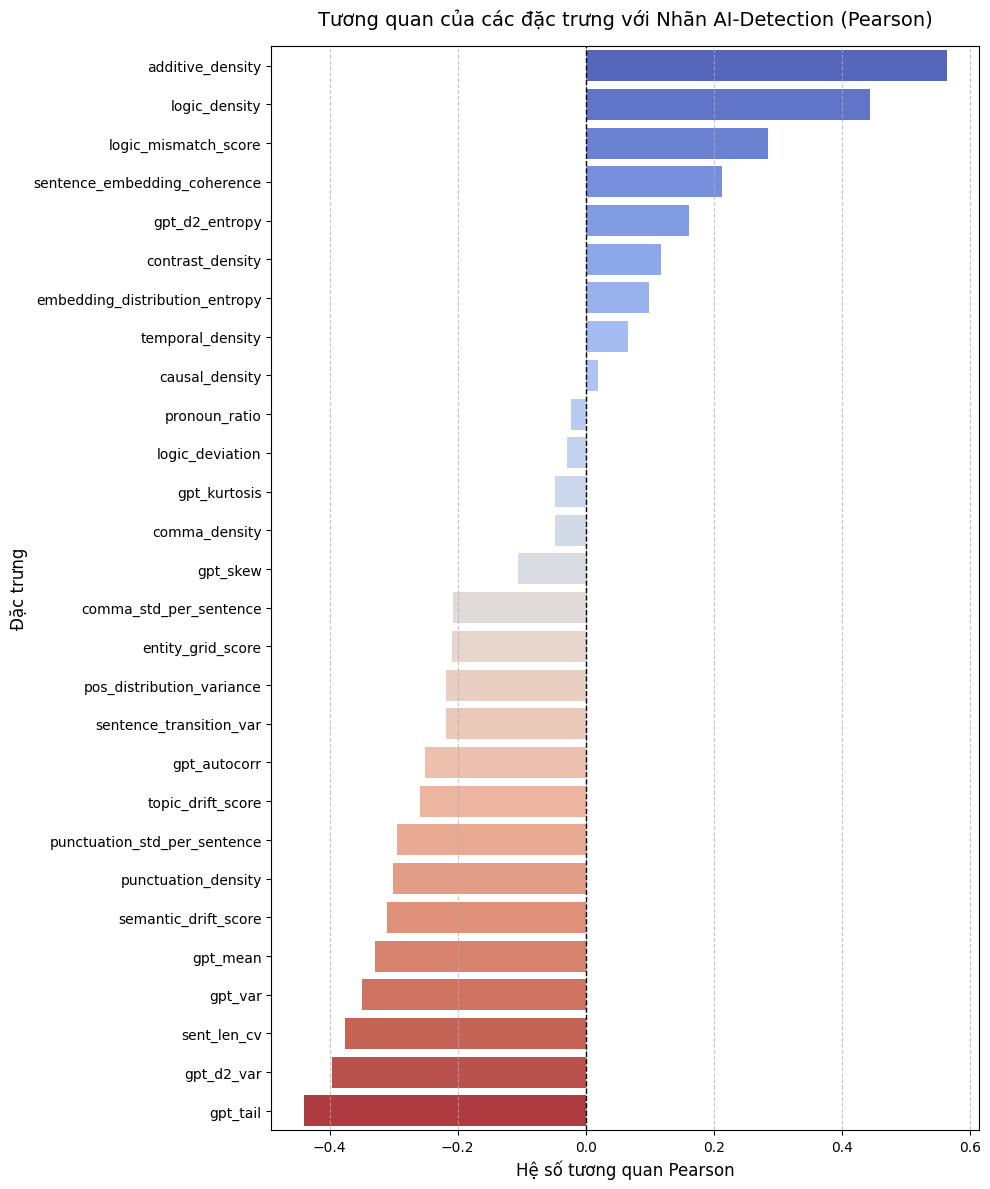

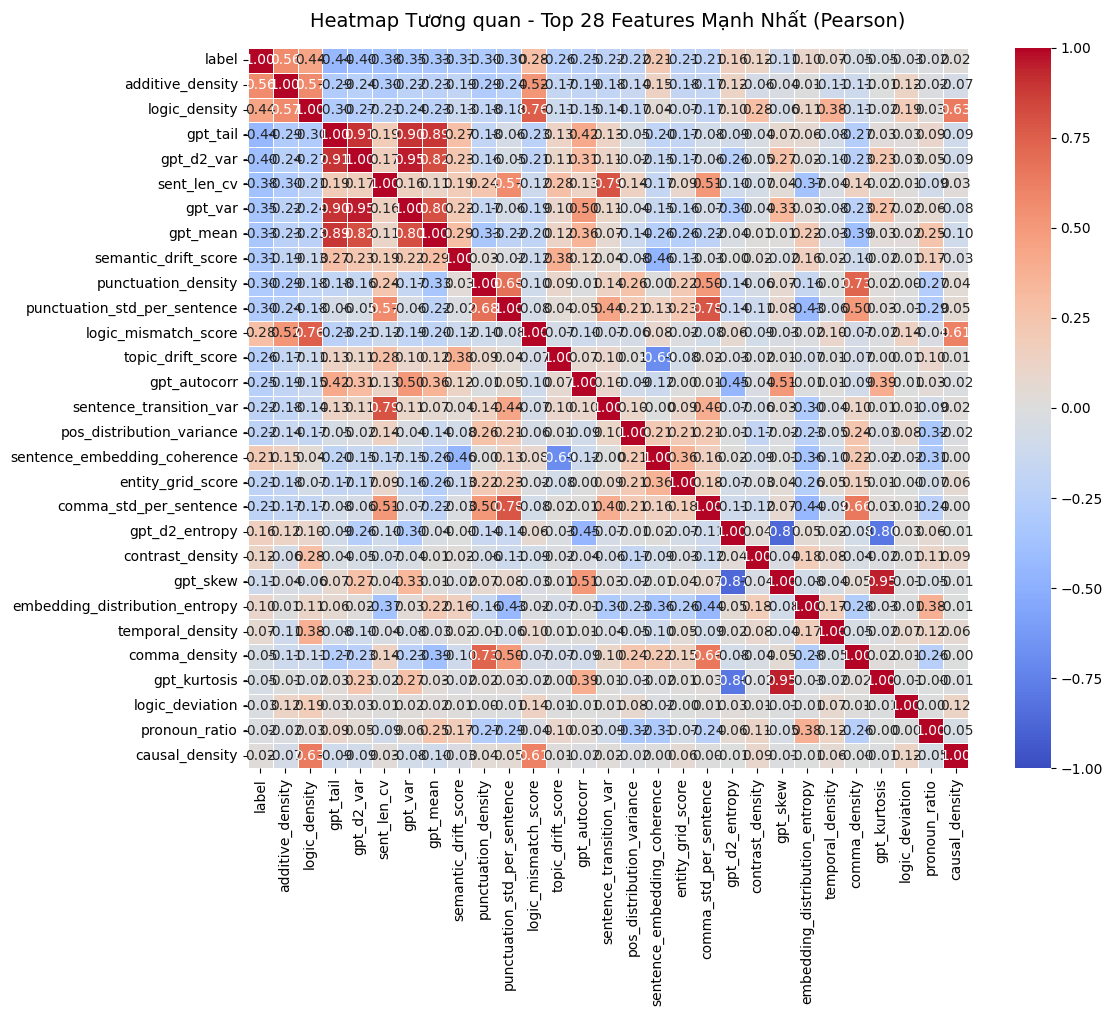

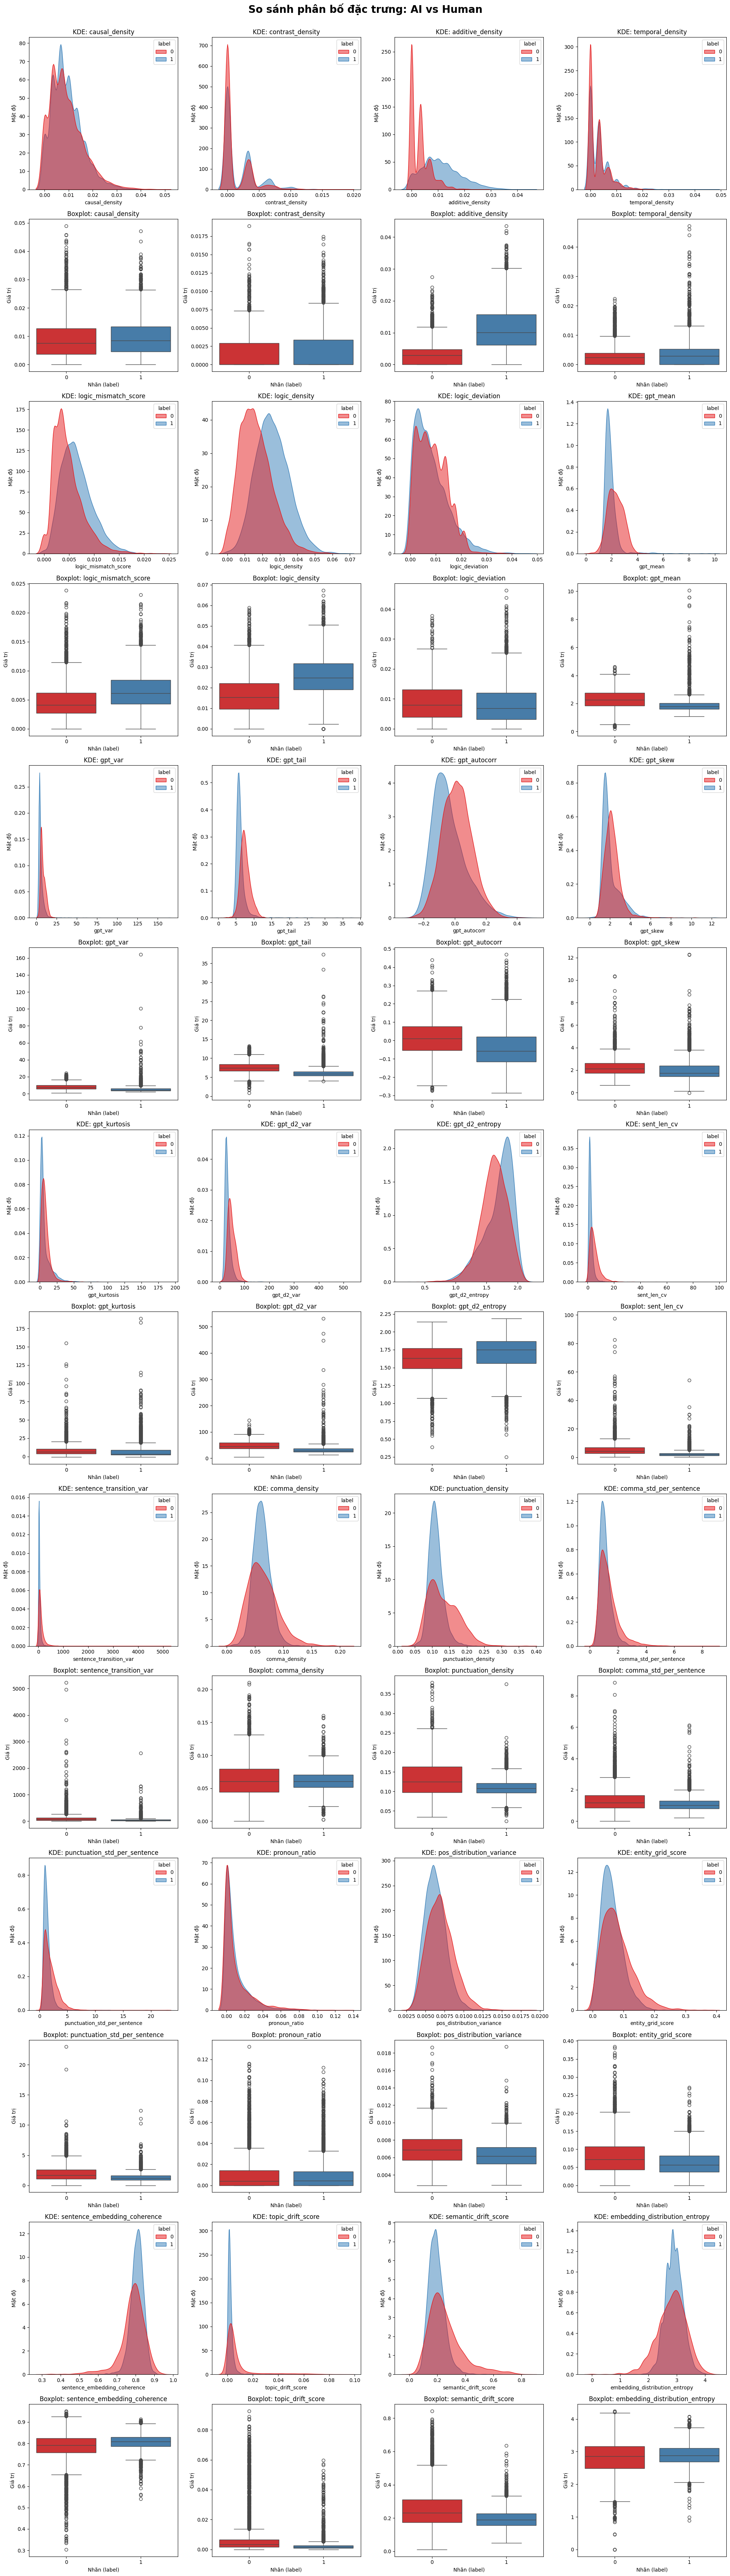

Đang huấn luyện Random Forest để trích xuất Feature Importance...


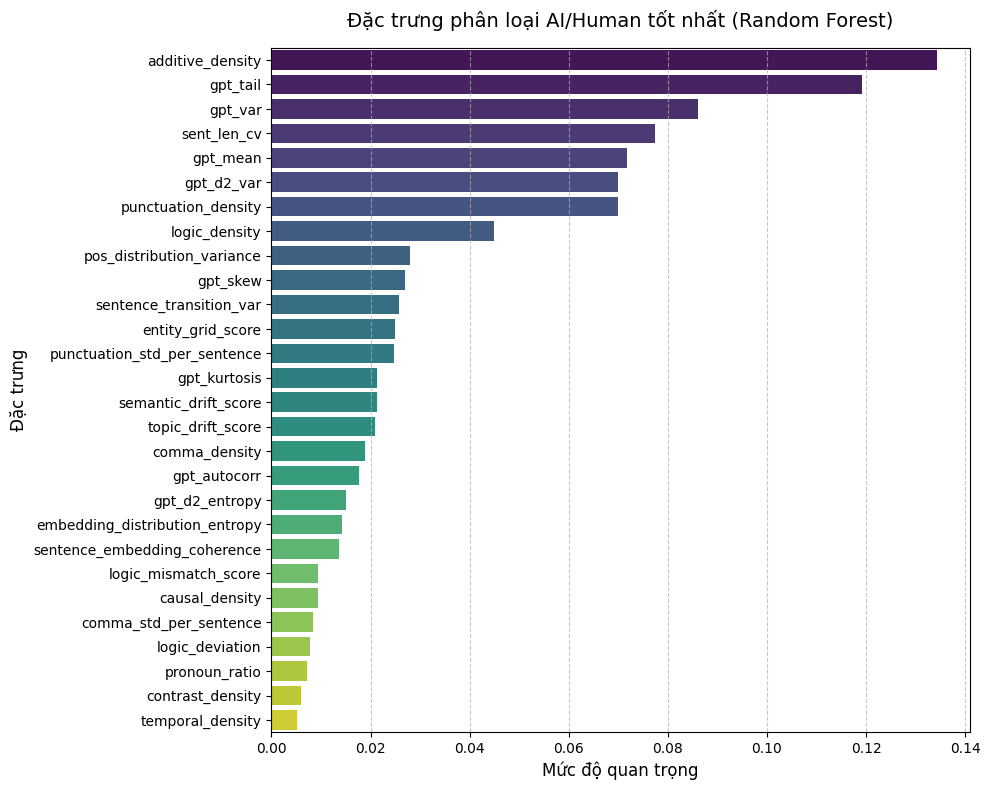

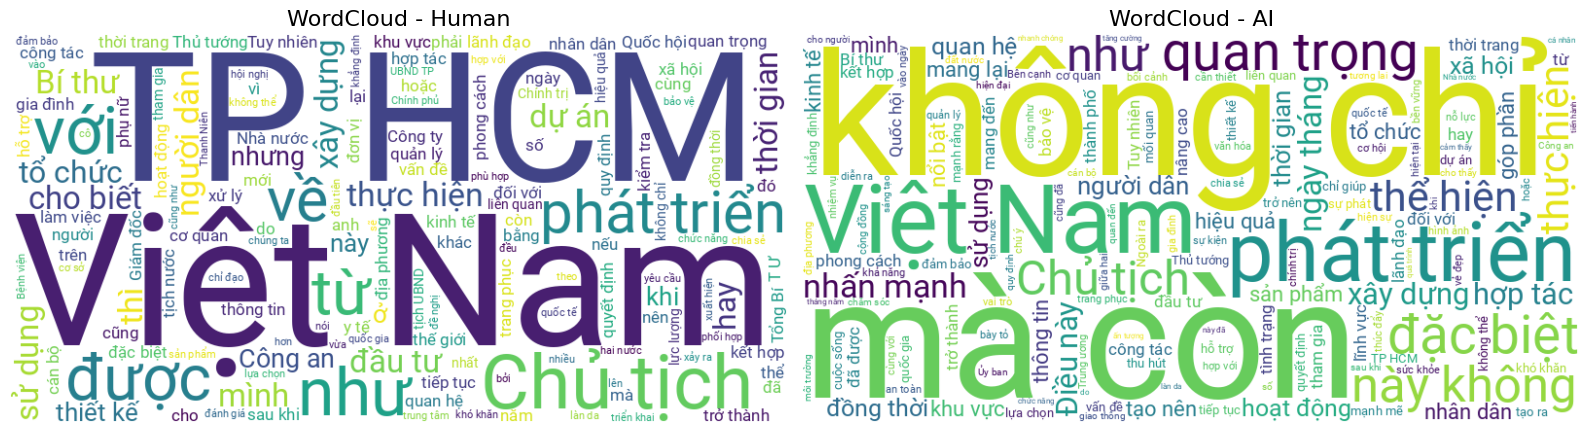

HOÀN THÀNH!


In [ ]:
visualizer = AIDetectionDataVisualizer(df, label_col='label', text_col='text')
visualizer.analyze_all()

In [ ]:
class AIFeatureEvaluator:
    def __init__(self, df_train, df_ood, label_col='label', top_k_interact=3, random_state=42):
        self.df_train = df_train.copy()
        self.df_ood = df_ood.copy()
        self.label_col = label_col
        self.top_k_interact = top_k_interact
        self.random_state = random_state

        self.CLASS_A = [
            'sent_len_cv', 'comma_density', 'pos_distribution_variance',
            'entity_grid_score', 'causal_density', 'temporal_density', 'logic_density',
            'punctuation_density', 'transition_density'
        ]

        self.CLASS_B = [
            'gpt_mean', 'gpt_d2_entropy', 'logic_deviation',
            'additive_density', 'gpt_var', 'gpt_tail',
            'embedding_distribution_entropy', 'topic_drift_score', 'contrast_density',
            'sentence_embedding_coherence', 'semantic_drift_score',
            'gpt_var_x_semantic_drift', 'gpt_mean_x_embedding_coherence',
            'gpt_tail_x_semantic_drift', 'logic_deviation_x_embedding_coherence',
            'embedding_coherence_x_entropy', 'semantic_drift_x_entropy',
            'semantic_drift_ratio', 'comma_density_x_gpt_var', 'combo_gpt_sent_punct'
        ]

        self.CLASS_C = [
            'gpt_d2_var', 'gpt_kurtosis', 'gpt_skew', 'gpt_autocorr',
            'sentence_transition_var',
            'comma_std_per_sentence', 'punctuation_std_per_sentence',
            'logic_mismatch_score', 'pronoun_ratio',
            'sent_len_cv_x_gpt_var', 'punctuation_density_x_gpt_mean',
            'logic_density_x_semantic_drift',
            'transition_density_x_gpt_var', 'sent_len_cv_ratio',
        ]
        self.features = [f for f in (self.CLASS_A + self.CLASS_B + self.CLASS_C) if f in self.df_train.columns]

        self._cluster_ood_topics()

    def _cluster_ood_topics(self):
        X_ood = self.df_ood[self.features].fillna(self.df_ood[self.features].median())
        n_clusters = min(3, len(X_ood))
        kmeans = KMeans(n_clusters=n_clusters, random_state=self.random_state, n_init=1)
        self.ood_topics = kmeans.fit_predict(X_ood)

    def _get_crosstopic_wd(self, feature):
        topics = np.unique(self.ood_topics)
        if len(topics) < 2: return 0.0

        max_wd = 0.0
        for i in range(len(topics)):
            for j in range(i + 1, len(topics)):
                dist1 = self.df_ood[self.ood_topics == topics[i]][feature].dropna()
                dist2 = self.df_ood[self.ood_topics == topics[j]][feature].dropna()
                if len(dist1) > 5 and len(dist2) > 5:
                    max_wd = max(max_wd, wasserstein_distance(dist1, dist2))
        return max_wd

    def _safe_jsd(self, a, b):
        if len(a) < 2 or len(b) < 2: return np.nan
        min_val, max_val = min(a.min(), b.min()), max(a.max(), b.max())
        if min_val == max_val: return 0.0
        bins = np.linspace(min_val, max_val, 50)
        p = np.histogram(a, bins=bins, density=True)[0] + 1e-10
        q = np.histogram(b, bins=bins, density=True)[0] + 1e-10
        return jensenshannon(p / p.sum(), q / q.sum())

    def _evaluate_univariate(self, feature, df_target):
        a = df_target[df_target[self.label_col] == 0][feature].dropna()
        b = df_target[df_target[self.label_col] == 1][feature].dropna()

        jsd = self._safe_jsd(a, b)
        ks = ks_2samp(a, b).statistic if len(a) > 1 and len(b) > 1 else np.nan
        mw_p = mannwhitneyu(a, b).pvalue if len(a) > 1 and len(b) > 1 else np.nan
        wd = wasserstein_distance(a, b) if len(a) > 1 and len(b) > 1 else np.nan

        try:
            auc = roc_auc_score(df_target[self.label_col], df_target[feature])
            auc = max(auc, 1 - auc)
        except:
            auc = np.nan

        return jsd, ks, mw_p, wd, auc

    def extract_importance_and_shap(self):
        print("Huấn luyện XGBoost để trích xuất Importance & Top-K SHAP Interactions...")
        X_train, y_train = self.df_train[self.features], self.df_train[self.label_col]
        X_ood, y_ood = self.df_ood[self.features], self.df_ood[self.label_col]

        model_train = xgb.XGBClassifier(n_estimators=50, max_depth=4, random_state=self.random_state)
        model_train.fit(X_train, y_train)

        model_ood = xgb.XGBClassifier(n_estimators=50, max_depth=4, random_state=self.random_state)
        model_ood.fit(X_ood, y_ood)

        importance_train = dict(zip(self.features, model_train.feature_importances_))
        importance_ood = dict(zip(self.features, model_ood.feature_importances_))

        explainer = shap.TreeExplainer(model_train)
        sample_ood = X_ood.iloc[:min(500, len(X_ood))]
        shap_interaction_values = explainer.shap_interaction_values(sample_ood)

        interaction_strength = {}
        for i, f in enumerate(self.features):
            interact_matrix = np.abs(shap_interaction_values[:, i, :])
            mean_interact_per_feature = np.mean(interact_matrix, axis=0)
            mean_interact_per_feature[i] = 0
            top_k_vals = np.sort(mean_interact_per_feature)[-self.top_k_interact:]
            interaction_strength[f] = np.mean(top_k_vals)

        return importance_train, importance_ood, interaction_strength

    def evaluate_features(self, w1=0.6, w2=0.4):
        print("Đang tính toán Final Stability (Normalized) và kiểm tra các điều kiện...")
        imp_train, imp_ood, interact_strength = self.extract_importance_and_shap()

        raw_metrics = {}
        max_imp_diff = 0.0
        max_dist_shift = 0.0

        for f in self.features:
            shift_jsd = self._safe_jsd(self.df_train[f].dropna(), self.df_ood[f].dropna())
            shift_wd = wasserstein_distance(self.df_train[f].dropna(), self.df_ood[f].dropna())

            imp_diff = abs(imp_train.get(f, 0) - imp_ood.get(f, 0))
            dist_shift = (shift_jsd if not np.isnan(shift_jsd) else 0) + (shift_wd if not np.isnan(shift_wd) else 0)

            if imp_diff > max_imp_diff: max_imp_diff = imp_diff
            if dist_shift > max_dist_shift: max_dist_shift = dist_shift

            raw_metrics[f] = {
                'shift_jsd': shift_jsd,
                'shift_wd': shift_wd,
                'imp_diff': imp_diff,
                'dist_shift': dist_shift
            }

        max_imp_diff = max_imp_diff if max_imp_diff > 0 else 1e-9
        max_dist_shift = max_dist_shift if max_dist_shift > 0 else 1e-9

        results = []
        for f in self.features:
            metrics = raw_metrics[f]

            imp_diff_norm = metrics['imp_diff'] / max_imp_diff
            dist_shift_norm = metrics['dist_shift'] / max_dist_shift

            final_stability = w1 * imp_diff_norm + w2 * dist_shift_norm

            jsd_ood, ks_ood, mw_p_ood, wd_ood, auc_ood = self._evaluate_univariate(f, self.df_ood)
            crosstopic_wd = self._get_crosstopic_wd(f)

            _class = 'A' if f in self.CLASS_A else ('B' if f in self.CLASS_B else 'C')

            results.append({
                'Feature': f,
                'Class': _class,
                'Imp_Train': imp_train.get(f, 0),
                'Imp_OOD': imp_ood.get(f, 0),
                'Imp_Diff': metrics['imp_diff'],
                'Imp_Diff_Norm': imp_diff_norm,
                'Dist_Shift': metrics['dist_shift'],
                'Dist_Shift_Norm': dist_shift_norm,
                'Final_Stability': final_stability,
                'TopK_SHAP_Interaction': interact_strength.get(f, 0),
                'CrossTopic_WD': crosstopic_wd,
                'OOD_AUC': auc_ood,
                'OOD_JSD': jsd_ood,
                'OOD_WD': wd_ood
            })

        df_results = pd.DataFrame(results)
        return self._make_decisions(df_results)

    def _make_decisions(self, df_res):
        decisions = []

        shap_75th = np.percentile(df_res['TopK_SHAP_Interaction'].dropna(), 75)
        shap_85th = np.percentile(df_res['TopK_SHAP_Interaction'].dropna(), 85)

        for _, row in df_res.iterrows():
            f = row['Feature']
            c = row['Class']
            action = "KEEP"
            notes = []

            if c == 'A':
                notes.append("Robust group. Strict Keep.")

            elif c == 'B':
                if row['Final_Stability'] < 0.2:
                    notes.append("Stable. Keep.")
                elif row['OOD_AUC'] < 0.55:
                    action = "DOWN_WEIGHT / AUX_HEAD"
                    notes.append("This features maybe need to be drop!")
                elif row['TopK_SHAP_Interaction'] > shap_75th:
                    notes.append(f"Unstable alone, but Top-{self.top_k_interact} interaction is strong. Keep.")
                else:
                    action = "DOWN_WEIGHT / AUX_HEAD"
                    notes.append("High Final Stability (Unstable) & Weak interaction.")

            elif c == 'C':
                cond1 = row['OOD_JSD'] > 0.15
                cond2 = row['OOD_AUC'] > 0.60
                cond3 = row['Imp_OOD'] > 0
                cond4 = row['Final_Stability'] < 0.3
                cond5 = row['CrossTopic_WD'] < 0.25

                if cond1 and cond2 and cond3 and cond4 and cond5:
                    action = "KEEP_WITH_EXTREME_CLIPPING"
                    notes.append("Passed all strict thresholds including CrossTopic_WD. Requires 1%-99% clip.")
                elif row['TopK_SHAP_Interaction'] > shap_85th:
                    action = "KEEP_WITH_EXTREME_CLIPPING"
                    notes.append(f"Failed univariate, but exceptional Top-{self.top_k_interact} interaction. Save & Clip.")
                else:
                    action = "DROP"
                    notes.append(f"Failed criteria (AUC={row['OOD_AUC']:.2f}, CrossTopic_WD={row['CrossTopic_WD']:.2f}).")

            decisions.append({'Feature': f, 'Action': action, 'Reason': " ".join(notes)})

        return df_res.merge(pd.DataFrame(decisions), on='Feature')

In [ ]:
df_train = pd.read_csv("Data/iccies_dataset_eda_integration.csv")
df_ood =  pd.read_csv("Data/vietnamese_news_ai_dataset_eda_integration.csv")
evaluator = AIFeatureEvaluator(df_train=df_train, df_ood=df_ood, label_col='label')
evaluation_results = evaluator.evaluate_features()

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

print("KẾT QUẢ ĐÁNH GIÁ ĐẶC TRƯNG:")
display(evaluation_results[['Feature', 'Class', 'Final_Stability', 'OOD_AUC', 'Action', 'Reason']])

Đang tính toán Final Stability (Normalized) và kiểm tra các điều kiện...
Huấn luyện XGBoost để trích xuất Importance & Top-K SHAP Interactions...
KẾT QUẢ ĐÁNH GIÁ ĐẶC TRƯNG:


,Feature,Class,Final_Stability,OOD_AUC,Action,Reason
0,sent_len_cv,A,0.035629,0.647214,KEEP,Robust group. Strict Keep.
1,comma_density,A,0.017483,0.575469,KEEP,Robust group. Strict Keep.
2,pos_distribution_variance,A,0.017446,0.602347,KEEP,Robust group. Strict Keep.
3,entity_grid_score,A,0.013183,0.597624,KEEP,Robust group. Strict Keep.
4,causal_density,A,0.007842,0.522482,KEEP,Robust group. Strict Keep.
5,temporal_density,A,0.021157,0.557050,KEEP,Robust group. Strict Keep.
6,logic_density,A,0.006774,0.644023,KEEP,Robust group. Strict Keep.
7,punctuation_density,A,0.067448,0.812190,KEEP,Robust group. Strict Keep.
8,transition_density,A,0.002636,0.644012,KEEP,Robust group. Strict Keep.
9,gpt_mean,B,0.072189,0.578184,KEEP,Stable. Keep.


In [ ]:
class AIFeatureProcessor:
    def __init__(self, length_col='word_count', text_col='text', label_col='label', top_k_interact=3, random_state=42):
        self.length_col = length_col
        self.text_col = text_col
        self.label_col = label_col
        self.top_k_interact = top_k_interact
        self.random_state = random_state

        self.CLASS_A = [
            'sent_len_cv', 'comma_density', 'pos_distribution_variance',
            'entity_grid_score', 'causal_density', 'temporal_density', 'logic_density',
            'punctuation_density', 'transition_density'
        ]

        self.CLASS_B = [
            'gpt_mean', 'gpt_d2_entropy', 'logic_deviation',
            'additive_density', 'gpt_var', 'gpt_tail',
            'embedding_distribution_entropy', 'topic_drift_score', 'contrast_density',
            'sentence_embedding_coherence', 'semantic_drift_score',
            'gpt_var_x_semantic_drift', 'gpt_mean_x_embedding_coherence',
            'gpt_tail_x_semantic_drift', 'logic_deviation_x_embedding_coherence',
            'embedding_coherence_x_entropy', 'semantic_drift_x_entropy',
            'semantic_drift_ratio', 'comma_density_x_gpt_var', 'combo_gpt_sent_punct'
        ]

        self.CLASS_C = [
            'gpt_d2_var', 'gpt_kurtosis', 'gpt_skew', 'gpt_autocorr',
            'sentence_transition_var',
            'comma_std_per_sentence', 'punctuation_std_per_sentence',
            'logic_mismatch_score', 'pronoun_ratio',
            'sent_len_cv_x_gpt_var', 'punctuation_density_x_gpt_mean',
            'logic_density_x_semantic_drift',
            'transition_density_x_gpt_var', 'sent_len_cv_ratio',
        ]

        self.features = []
        self.cols_to_drop = []
        self.clip_thresholds = {}
        self.is_fitted = False

    def _cluster_ood_topics(self, df_ood):
        X_ood = df_ood[self.features].fillna(df_ood[self.features].median())
        n_clusters = min(3, len(X_ood))
        kmeans = KMeans(n_clusters=n_clusters, random_state=self.random_state, n_init=1)
        return kmeans.fit_predict(X_ood)

    def _get_crosstopic_wd(self, feature, df_ood, ood_topics):
        topics = np.unique(ood_topics)
        if len(topics) < 2: return 0.0
        max_wd = 0.0
        for i in range(len(topics)):
            for j in range(i + 1, len(topics)):
                dist1 = df_ood[ood_topics == topics[i]][feature].dropna()
                dist2 = df_ood[ood_topics == topics[j]][feature].dropna()
                if len(dist1) > 5 and len(dist2) > 5:
                    max_wd = max(max_wd, wasserstein_distance(dist1, dist2))
        return max_wd

    def _safe_jsd(self, a, b):
        if len(a) < 2 or len(b) < 2: return np.nan
        min_val, max_val = min(a.min(), b.min()), max(a.max(), b.max())
        if min_val == max_val: return 0.0
        bins = np.linspace(min_val, max_val, 50)
        p = np.histogram(a, bins=bins, density=True)[0] + 1e-10
        q = np.histogram(b, bins=bins, density=True)[0] + 1e-10
        return jensenshannon(p / p.sum(), q / q.sum())

    def _evaluate_univariate(self, feature, df_target):
        a = df_target[df_target[self.label_col] == 0][feature].dropna()
        b = df_target[df_target[self.label_col] == 1][feature].dropna()
        jsd = self._safe_jsd(a, b)
        ks = ks_2samp(a, b).statistic if len(a) > 1 and len(b) > 1 else np.nan
        mw_p = mannedwhitneyu(a, b).pvalue if len(a) > 1 and len(b) > 1 else np.nan
        wd = wasserstein_distance(a, b) if len(a) > 1 and len(b) > 1 else np.nan
        try:
            auc = roc_auc_score(df_target[self.label_col], df_target[feature])
            auc = max(auc, 1 - auc)
        except:
            auc = np.nan
        return jsd, ks, mw_p, wd, auc

    def _extract_importance_and_shap(self, df_train, df_ood):
        X_train, y_train = df_train[self.features], df_train[self.label_col]
        X_ood, y_ood = df_ood[self.features], df_ood[self.label_col]

        model_train = xgb.XGBClassifier(n_estimators=50, max_depth=4, random_state=self.random_state)
        model_train.fit(X_train, y_train)

        model_ood = xgb.XGBClassifier(n_estimators=50, max_depth=4, random_state=self.random_state)
        model_ood.fit(X_ood, y_ood)

        importance_train = dict(zip(self.features, model_train.feature_importances_))
        importance_ood = dict(zip(self.features, model_ood.feature_importances_))

        explainer = shap.TreeExplainer(model_train)
        sample_ood = X_ood.iloc[:min(500, len(X_ood))]
        shap_interaction_values = explainer.shap_interaction_values(sample_ood)

        interaction_strength = {}
        for i, f in enumerate(self.features):
            interact_matrix = np.abs(shap_interaction_values[:, i, :])
            mean_interact_per_feature = np.mean(interact_matrix, axis=0)
            mean_interact_per_feature[i] = 0
            top_k_vals = np.sort(mean_interact_per_feature)[-self.top_k_interact:]
            interaction_strength[f] = np.mean(top_k_vals)

        return importance_train, importance_ood, interaction_strength

    def fit(self, df_train, df_ood, w1=0.6, w2=0.4):
        print("--- ĐANG ĐÁNH GIÁ VÀ PHÁT HIỆN ĐẶC TRƯNG ---")
        self.features = [f for f in (self.CLASS_A + self.CLASS_B + self.CLASS_C) if f in df_train.columns]

        ood_topics = self._cluster_ood_topics(df_ood)
        imp_train, imp_ood, interact_strength = self._extract_importance_and_shap(df_train, df_ood)

        raw_metrics = {}
        max_imp_diff = 0.0
        max_dist_shift = 0.0

        for f in self.features:
            shift_jsd = self._safe_jsd(df_train[f].dropna(), df_ood[f].dropna())
            shift_wd = wasserstein_distance(df_train[f].dropna(), df_ood[f].dropna())
            imp_diff = abs(imp_train.get(f, 0) - imp_ood.get(f, 0))
            dist_shift = (shift_jsd if not np.isnan(shift_jsd) else 0) + (shift_wd if not np.isnan(shift_wd) else 0)

            if imp_diff > max_imp_diff: max_imp_diff = imp_diff
            if dist_shift > max_dist_shift: max_dist_shift = dist_shift

            raw_metrics[f] = {
                'shift_jsd': shift_jsd, 'shift_wd': shift_wd,
                'imp_diff': imp_diff, 'dist_shift': dist_shift
            }

        max_imp_diff = max_imp_diff if max_imp_diff > 0 else 1e-9
        max_dist_shift = max_dist_shift if max_dist_shift > 0 else 1e-9

        results = []
        for f in self.features:
            metrics = raw_metrics[f]
            imp_diff_norm = metrics['imp_diff'] / max_imp_diff
            dist_shift_norm = metrics['dist_shift'] / max_dist_shift
            final_stability = w1 * imp_diff_norm + w2 * dist_shift_norm
            jsd_ood, ks_ood, mw_p_ood, wd_ood, auc_ood = self._evaluate_univariate(f, df_ood)
            crosstopic_wd = self._get_crosstopic_wd(f, df_ood, ood_topics)

            _class = 'A' if f in self.CLASS_A else ('B' if f in self.CLASS_B else 'C')
            results.append({
                'Feature': f, 'Class': _class, 'Final_Stability': final_stability,
                'TopK_SHAP_Interaction': interact_strength.get(f, 0),
                'CrossTopic_WD': crosstopic_wd, 'OOD_AUC': auc_ood, 'OOD_JSD': jsd_ood
            })

        df_res = pd.DataFrame(results)
        shap_75th = np.percentile(df_res['TopK_SHAP_Interaction'].dropna(), 75)

        self.cols_to_drop = [c for c in self.CLASS_C if c in df_train.columns]
        self.clip_thresholds = {}

        print("\n--- QUYẾT ĐỊNH XỬ LÝ (LỚP B) ---")
        for _, row in df_res[df_res['Class'] == 'B'].iterrows():
            f = row['Feature']

            needs_clipping = False
            if row['Final_Stability'] >= 0.2:
                if row['OOD_AUC'] >= 0.55:
                    if row['TopK_SHAP_Interaction'] > shap_75th:
                        needs_clipping = True
                    else:
                        needs_clipping = True

            if needs_clipping:
                lower_val = df_train[f].quantile(0.01)
                upper_val = df_train[f].quantile(0.99)
                self.clip_thresholds[f] = (lower_val, upper_val)
                print(f"[{f}] Phát hiện Unstable -> Cài đặt mốc Clipping 1%-99%: [{lower_val:.4f}, {upper_val:.4f}]")
            else:
                print(f"[{f}] Đánh giá Stable -> GIỮ NGUYÊN")

        self.is_fitted = True
        return self

    def transform(self, df):
        if not self.is_fitted:
            raise ValueError("Phải gọi hàm fit() trên tập train và OOD trước khi transform().")

        df_out = df.copy()

        cols_to_drop_actual = [c for c in self.cols_to_drop if c in df_out.columns]
        df_out = df_out.drop(columns=cols_to_drop_actual)

        for col, (lower_val, upper_val) in self.clip_thresholds.items():
            if col in df_out.columns:
                df_out[col] = np.clip(df_out[col], a_min=lower_val, a_max=upper_val)

        return df_out

In [ ]:
df_train = pd.read_csv("Data/iccies_dataset_eda_integration.csv")
df_ood =  pd.read_csv("Data/vietnamese_news_ai_dataset_eda_integration.csv")

processor = AIFeatureProcessor(length_col='word_count', text_col='text', label_col='label')

print("Đang xử lý dữ liệu...\n")
processor.fit(df_train, df_ood)

df_train_cleaned = processor.transform(df_train)
df_ood_cleaned = processor.transform(df_ood)

final_dir = "Data/Final"
os.makedirs(final_dir, exist_ok=True)
df_train_cleaned.to_csv(f"{final_dir}/iccies_dataset_feature_integration_cleaned.csv", index=False)
df_ood_cleaned.to_csv(f"{final_dir}/vietnamese_news_ai_dataset_feature_integration_cleaned.csv", index=False)

df_train.to_csv(f"{final_dir}/iccies_dataset_raw.csv", index=False)
df_ood.to_csv(f"{final_dir}/vietnamese_news_ai_dataset_raw.csv", index=False)

print(f"\nĐã hoàn tất lưu dữ liệu vào thư mục: {final_dir}")
print(f"- Dữ liệu Train sạch: {len(df_train_cleaned.columns)} cột (Gốc: {len(df_train.columns)} cột)")
print(f"- Dữ liệu OOD sạch: {len(df_ood_cleaned.columns)} cột (Gốc: {len(df_ood.columns)} cột)")

Đang xử lý dữ liệu...

--- ĐANG ĐÁNH GIÁ VÀ PHÁT HIỆN ĐẶC TRƯNG ---

--- QUYẾT ĐỊNH XỬ LÝ (LỚP B) ---
[gpt_mean] Đánh giá Stable -> GIỮ NGUYÊN
[gpt_d2_entropy] Đánh giá Stable -> GIỮ NGUYÊN
[logic_deviation] Đánh giá Stable -> GIỮ NGUYÊN
[additive_density] Đánh giá Stable -> GIỮ NGUYÊN
[gpt_var] Đánh giá Stable -> GIỮ NGUYÊN
[gpt_tail] Đánh giá Stable -> GIỮ NGUYÊN
[embedding_distribution_entropy] Đánh giá Stable -> GIỮ NGUYÊN
[topic_drift_score] Đánh giá Stable -> GIỮ NGUYÊN
[contrast_density] Đánh giá Stable -> GIỮ NGUYÊN
[sentence_embedding_coherence] Đánh giá Stable -> GIỮ NGUYÊN
[semantic_drift_score] Đánh giá Stable -> GIỮ NGUYÊN
[gpt_var_x_semantic_drift] Đánh giá Stable -> GIỮ NGUYÊN
[gpt_mean_x_embedding_coherence] Đánh giá Stable -> GIỮ NGUYÊN
[gpt_tail_x_semantic_drift] Đánh giá Stable -> GIỮ NGUYÊN
[logic_deviation_x_embedding_coherence] Đánh giá Stable -> GIỮ NGUYÊN
[embedding_coherence_x_entropy] Đánh giá Stable -> GIỮ NGUYÊN
[semantic_drift_x_entropy] Đánh giá Stable -> 

In [ ]:
class DataReportVisualizers:
    def __init__(self, dataframe=None, label_col='label'):
        self.df = dataframe.copy() if dataframe is not None else None
        self.label_col = label_col
        sns.set_theme(style="whitegrid", rc={"axes.edgecolor": "black", "axes.linewidth": 1})

    def plot_label_distribution(self, figsize=(8, 8)):
        if self.df is None or self.label_col not in self.df.columns:
            return

        counts = self.df[self.label_col].value_counts()

        def make_autopct(values):
            def my_autopct(pct):
                total = sum(values)
                val = int(round(pct * total / 100.0))
                return f'{pct:.1f}%\n({val:,} mẫu)'
            return my_autopct

        plt.figure(figsize=figsize)
        plt.pie(counts, labels=[f"Nhãn {i}" for i in counts.index],
                autopct=make_autopct(counts), startangle=140,
                colors=['#4C72B0', '#DD8452'],
                textprops={'fontsize': 12, 'weight': 'bold'},
                wedgeprops={'edgecolor': 'white', 'linewidth': 2})

        plt.title(f"Phân bố dữ liệu theo Nhãn (Tổng: {len(self.df):,} mẫu)", fontsize=16, pad=20)
        plt.tight_layout()
        plt.show()

    def plot_feature_comparison(self, features, normalize=True, figsize=(12, 6)):
        if self.df is None or self.label_col not in self.df.columns:
            return

        temp_df = self.df[[self.label_col] + features].copy()

        if normalize:
            scaler = MinMaxScaler()
            temp_df[features] = scaler.fit_transform(temp_df[features])
            y_label = "Giá trị trung bình (Đã chuẩn hóa Min-Max [0-1])"
            title_suffix = "(Đã chuẩn hóa)"
        else:
            y_label = "Giá trị trung bình gốc"
            title_suffix = "(Giá trị gốc - Lưu ý lệch thang đo)"

        grouped = temp_df.groupby(self.label_col)[features].mean().reset_index()
        melted = grouped.melt(id_vars=self.label_col, var_name='Đặc trưng', value_name='Giá trị')

        plt.figure(figsize=figsize)
        sns.barplot(data=melted, x='Đặc trưng', y='Giá trị', hue=self.label_col, palette=['#4C72B0', '#DD8452'])

        plt.title(f"So sánh Giá trị trung bình các Đặc trưng {title_suffix}", fontsize=14, pad=15)
        plt.xlabel("Đặc trưng", fontsize=12)
        plt.ylabel(y_label, fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.legend(title=f"Nhãn ({self.label_col})")
        plt.tight_layout()
        plt.show()


    def generate_report_plots(self, comparison_features):
        self.plot_label_distribution()
        print("\n" + "-"*80 + "\n")
        self.plot_feature_comparison(comparison_features, normalize=True)


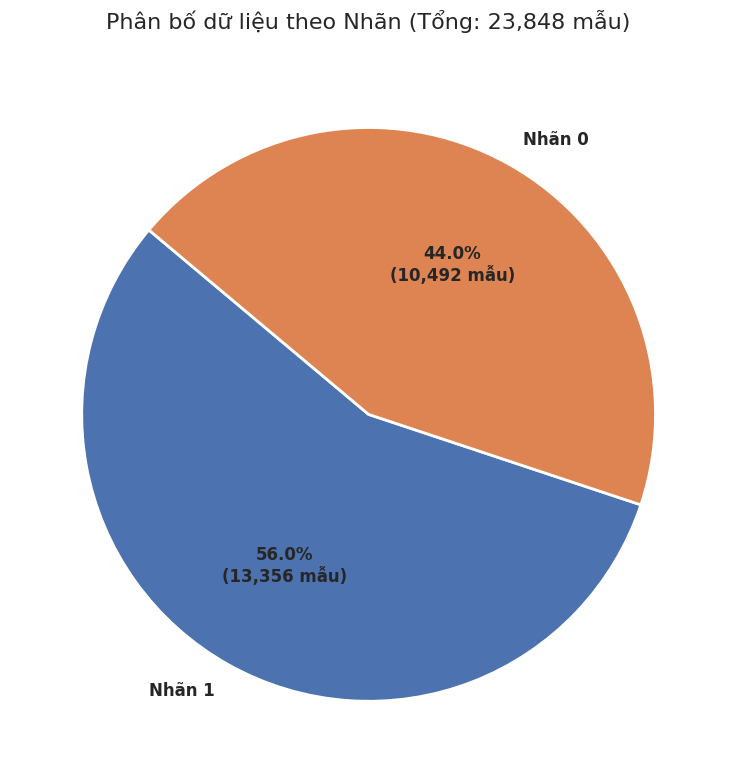


--------------------------------------------------------------------------------



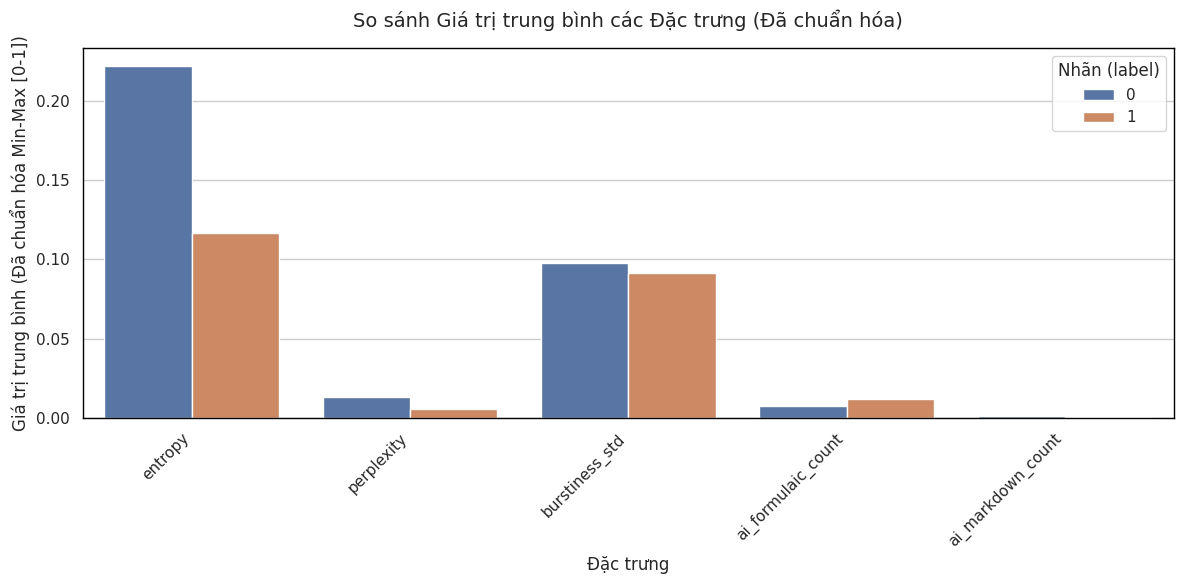

In [ ]:
report_viz = DataReportVisualizers(df, label_col='label')

ai_features = ['entropy', 'perplexity', 'burstiness_std', 'ai_formulaic_count', 'ai_markdown_count']
report_viz.generate_report_plots(ai_features)